<a href="https://colab.research.google.com/github/GustavoABrandao/Projeto---IA-Facens/blob/main/Projeto%20Big%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [190]:
# Importando bibliotecas necessárias
!pip install mlflow
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import expr
from pyspark.sql.functions import col, regexp_extract
from pyspark.sql.functions import expr, current_date, year as spark_year
import matplotlib.pyplot as plt
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType

spark = SparkSession.builder \
    .appName("PySpark Docker Example") \
    .getOrCreate()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [ ]:
dataframe = spark.read.csv("/content/vehicles.csv", header=True, inferSchema=True)
num_linhas = dataframe.count()
print(f"Número de linhas no DataFrame: {num_linhas}")

Número de linhas no DataFrame: 441802


In [ ]:
dataframe.show(50)

+----------+--------------------+--------------------+--------------------+-----+----+------------+--------------------+---------+-----------+-----+--------+------------+------------+-----------------+-----+---------+------+-----------+--------------------+--------------------+------+-----+-------+----------+--------------------+
|        id|                 url|              region|          region_url|price|year|manufacturer|               model|condition|  cylinders| fuel|odometer|title_status|transmission|              VIN|drive|     size|  type|paint_color|           image_url|         description|county|state|    lat|      long|        posting_date|
+----------+--------------------+--------------------+--------------------+-----+----+------------+--------------------+---------+-----------+-----+--------+------------+------------+-----------------+-----+---------+------+-----------+--------------------+--------------------+------+-----+-------+----------+--------------------+
|722

In [ ]:
df = dataframe

# Regex mais flexível: ignora o que não for número/ponto/sinal de menos
# Removemos o sinal de negativo de colunas que não podem ser negativas (preço, ano, km)
df = df.withColumn(
    "year",
    expr("try_cast(regexp_replace(year, '[^0-9]', '') as double)")
)

df = df.withColumn(
    "price",
    expr("try_cast(regexp_replace(price, '[^0-9.]', '') as double)")
)

df = df.withColumn(
    "odometer",
    expr("try_cast(regexp_replace(odometer, '[^0-9.]', '') as double)")
)

df = df.withColumn(
    "lat",
    expr("try_cast(regexp_replace(lat, '[^0-9.-]', '') as double)")
)

df = df.withColumn(
    "long",
    expr("try_cast(regexp_replace(long, '[^0-9.-]', '') as double)")
)

df = df.withColumn(
    "car_age",
    spark_year(current_date()) - col("year")
)
# Remoção de colunas
df = df.drop(
    "id", "url", "region_url", "VIN",
    "image_url", "description", "county",
    "posting_date", "size"
)

In [ ]:
# =========================
# 2. DROP E FILTROS (MENOS AGRESSIVO)
# =========================

# DICA: Removi lat e long do dropna. Se não tiver localização, a gente mantém o carro!
df = df.dropna(subset=["price", "year", "odometer"])

# Filtros de sanidade
df = df.filter(
    (col("price") >= 100.0) & (col("price") < 1000000.0) &
    (col("year") > 2005.0) & (col("year") <= 2026.0)
)


# VERIFICAÇÃO INTERMEDIÁRIA
contagem = df.count()
print(f"Registros após limpeza inicial: {contagem}")

if contagem > 0:
    # 3. CACHE E ESTATÍSTICA
    df.cache()

    for c in ["price", "odometer"]:
        # Verificamos se há dados suficientes para calcular quantis
        quantis = df.approxQuantile(c, [0.10, 0.90], 0.05)
        if len(quantis) == 2:
            q_low, q_high = quantis[0], quantis[1]
            df = df.filter((col(c) >= q_low) & (col(c) <= q_high))
            print(f"Filtro aplicado em {c}: {q_low} até {q_high}")

    print(f"Registros finais: {df.count()}")
else:
    print("ERRO: O filtro deletou todos os dados! Verifique as colunas de entrada.")
    df.show(5) # Mostra o que restou para você entender o problema

Registros após limpeza inicial: 324278
Filtro aplicado em price: 5000.0 até 35990.0
Filtro aplicado em odometer: 19240.0 até 147000.0
Registros finais: 186660


In [ ]:
# =========================
# 3. Colunas categóricas
# =========================

# One-hot (nominais)
categorical_cols = [
    "region", "manufacturer", "fuel", "transmission",
    "drive", "type", "paint_color", "state", "title_status"
]

# StringIndexer (ordinal ou alta cardinalidade)
index_cols = ["condition", "model"]




In [ ]:
# =========================
# 4. Criar stages
# =========================
stages = []

# Index + OneHot para categóricas nominais
for col_name in categorical_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    encoder = OneHotEncoder(
        inputCol=col_name + "_index",
        outputCol=col_name + "_onehot",
        dropLast=True
    )

    stages += [indexer, encoder]

# Apenas index para ordinal/alta cardinalidade
for col_name in index_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    stages.append(indexer)



In [ ]:
# =========================
# 5. Pipeline
# =========================
pipeline = Pipeline(stages=stages)
model = pipeline.fit(df)
df_prepared = model.transform(df)
df_prepared.createOrReplaceTempView("cars_prepared")


In [ ]:
features_sql = spark.sql("""
SELECT *
FROM cars_prepared
LIMIT 20
""")

features_sql.show()


+------+-------+------+------------+--------------------+---------+-----------+-----+--------+------------+------------+-----+--------+-----------+-----+---------+----------+-------+------------+-----------------+------------------+-------------------+----------+-------------+------------------+-------------------+-----------+-------------+----------+---------------+-----------------+------------------+-----------+-----------------+------------------+-------------------+---------------+-----------+
|region|  price|  year|manufacturer|               model|condition|  cylinders| fuel|odometer|title_status|transmission|drive|    type|paint_color|state|      lat|      long|car_age|region_index|    region_onehot|manufacturer_index|manufacturer_onehot|fuel_index|  fuel_onehot|transmission_index|transmission_onehot|drive_index| drive_onehot|type_index|    type_onehot|paint_color_index|paint_color_onehot|state_index|     state_onehot|title_status_index|title_status_onehot|condition_index|model

In [ ]:
df_prepared.createOrReplaceTempView("view_treino")

# Selecionamos as versões para o modelo
df_pre_treino = spark.sql("""
    SELECT
        price,
        car_age,
        odometer,
        lat,
        long,
        region_onehot,
        manufacturer_onehot,
        fuel_onehot,
        transmission_index,
        drive_onehot,
        type_onehot,
        paint_color_onehot,
        state_onehot,
        title_status_onehot,
        condition_index,
        model_index
    FROM view_treino
""")

df_pre_treino.show(50)


+-------+-------+--------+---------+----------+-----------------+-------------------+-------------+------------------+-------------+---------------+------------------+-----------------+-------------------+---------------+-----------+
|  price|car_age|odometer|      lat|      long|    region_onehot|manufacturer_onehot|  fuel_onehot|transmission_index| drive_onehot|    type_onehot|paint_color_onehot|     state_onehot|title_status_onehot|condition_index|model_index|
+-------+-------+--------+---------+----------+-----------------+-------------------+-------------+------------------+-------------+---------------+------------------+-----------------+-------------------+---------------+-----------+
|33590.0|   12.0| 57923.0|    32.59|    -85.48|(404,[333],[1.0])|     (38,[8],[1.0])|(5,[0],[1.0])|               1.0|    (3,[],[])| (13,[2],[1.0])|    (12,[0],[1.0])|(5801,[28],[1.0])|      (6,[0],[1.0])|            0.0|      175.0|
|22590.0|   16.0| 71229.0|    32.59|    -85.48|(404,[333],[1.0])

In [ ]:
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType

# Garante que a UDF para ler os vetores OneHot esteja definida
get_index = udf(lambda v: float(v.indices[0]) if len(v.indices) > 0 else -1.0, DoubleType())

# Combinação de todos os filtros em uma única operação
df_pre_treino = df_pre_treino \
    .withColumn("paint_temp_idx", get_index(col("paint_color_onehot"))) \
    .withColumn("drive_temp_idx", get_index(col("drive_onehot"))) \
    .filter(
        (~col("paint_temp_idx").isin([5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0])) &
        (~col("drive_temp_idx").isin([2.0])) &
        (~col("condition_index").isin([2.0, 3.0, 4.0, 5.0]))
    ) \
    .drop("paint_temp_idx", "drive_temp_idx")

# Opcional: Verifique o resultado
# print(f"Linhas após filtros: {df_pre_treino.count()}")

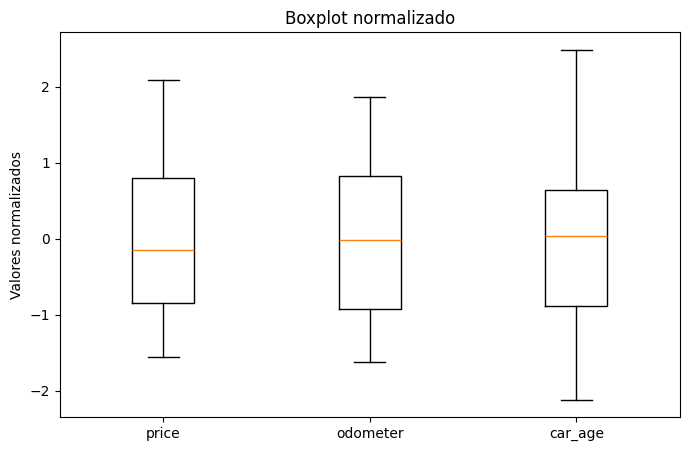

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data_norm = []

cols = ["price", "odometer", "car_age"]

for c in cols:
    sample = df_pre_treino.select(c) \
        .dropna() \
        .sample(False, 0.05, seed=42) \
        .rdd.map(lambda x: x[0]) \
        .collect()

    sample = np.array(sample)

    std = sample.std()

    if std != 0:
        sample = (sample - sample.mean()) / std
    else:
        sample = sample - sample.mean()  # evita divisão por zero

    data_norm.append(sample)

plt.figure(figsize=(8,5))
plt.boxplot(data_norm)
plt.xticks(range(1, len(cols)+1), cols)
plt.title("Boxplot normalizado")
plt.ylabel("Valores normalizados")
plt.show()

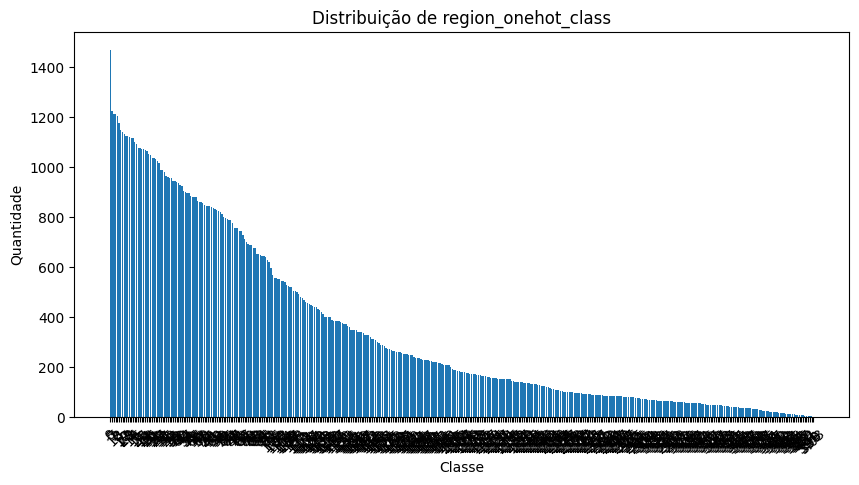

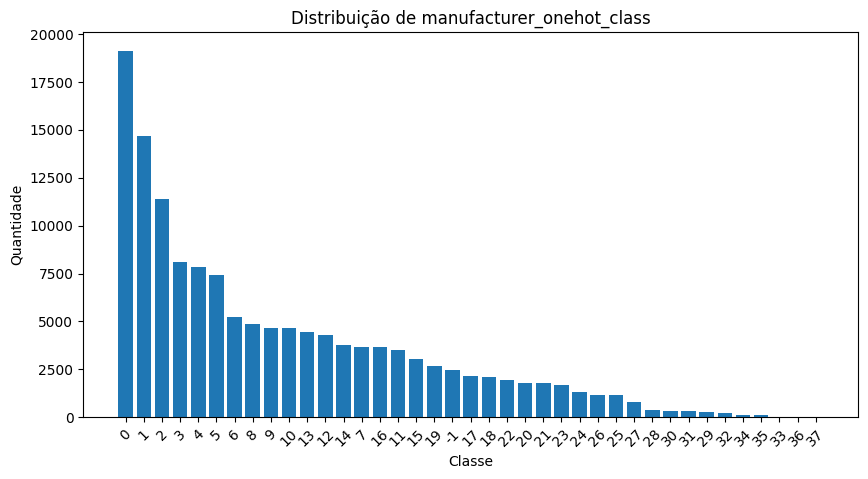

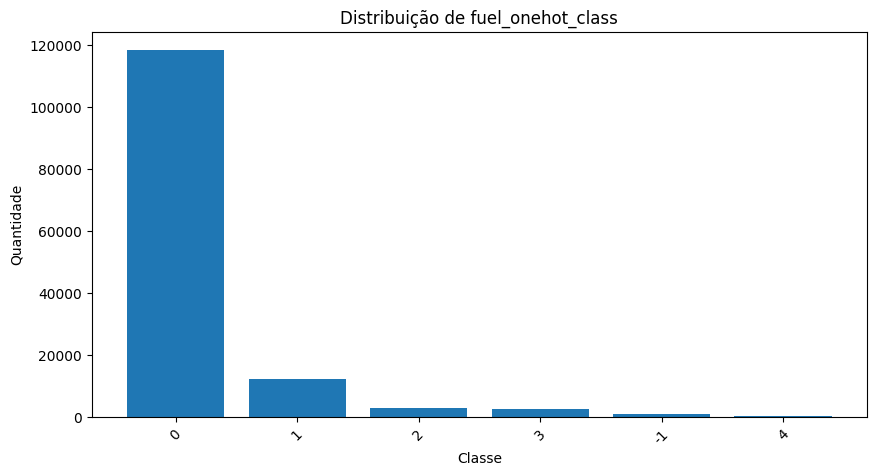

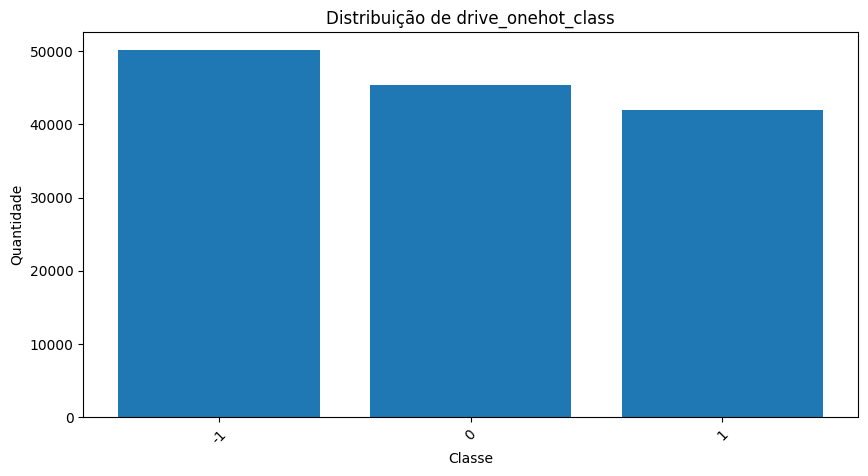

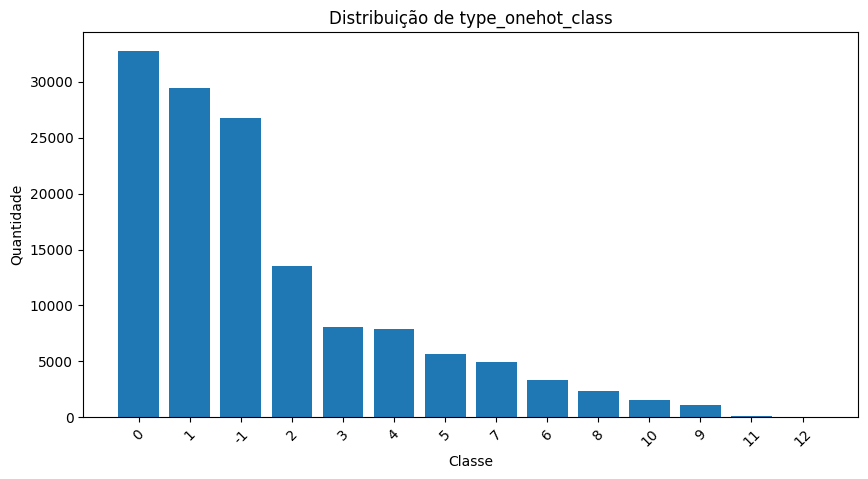

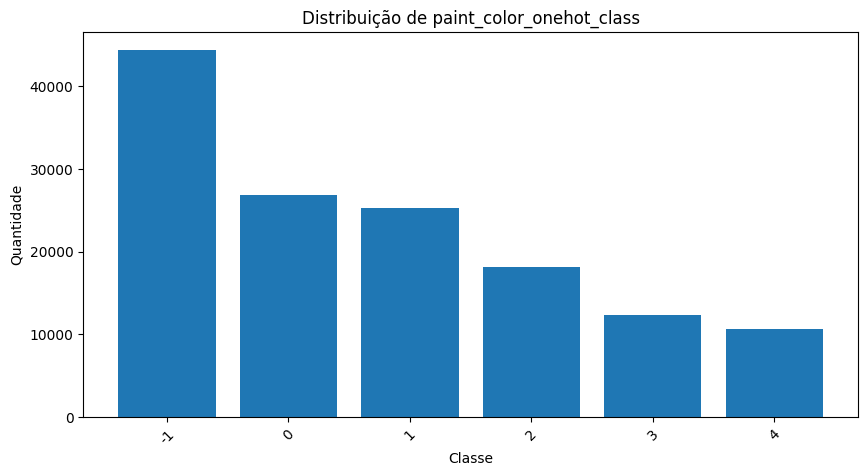

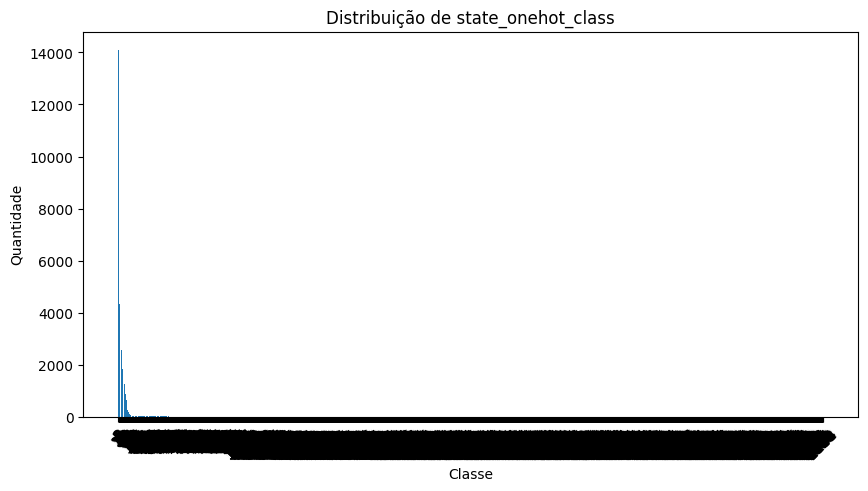

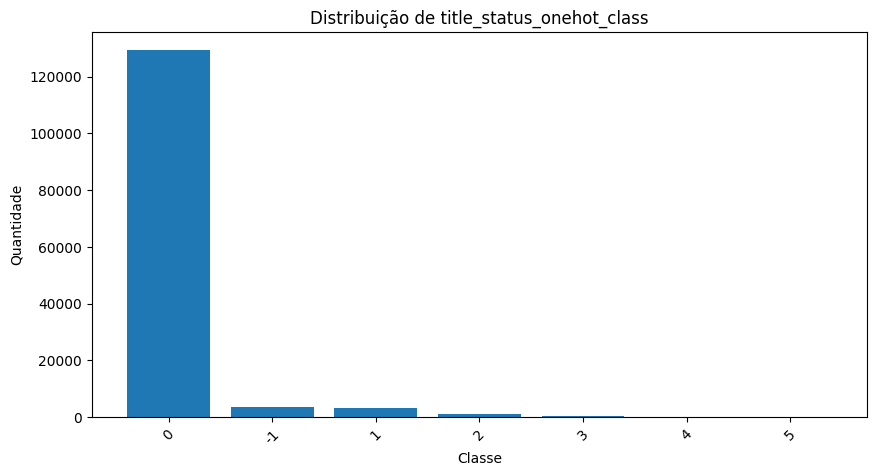

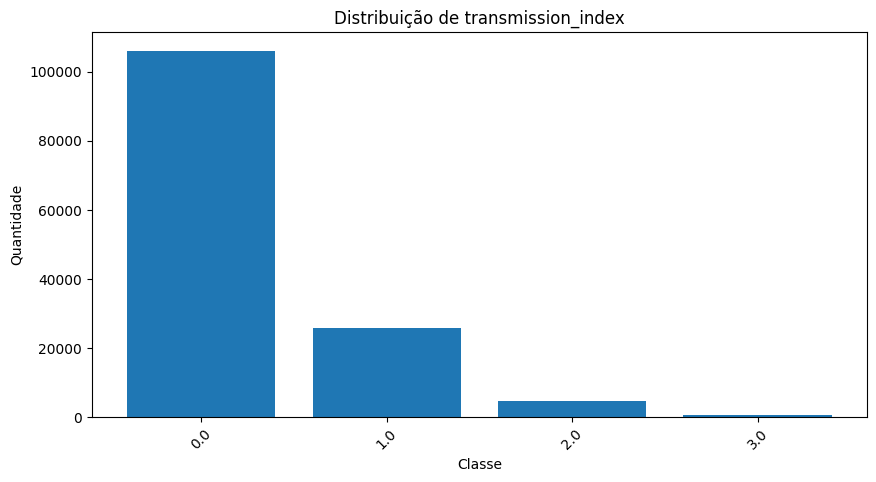

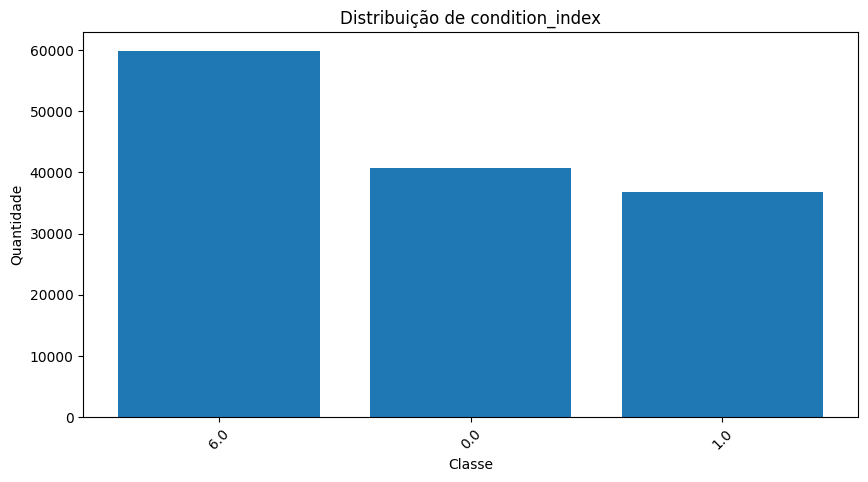

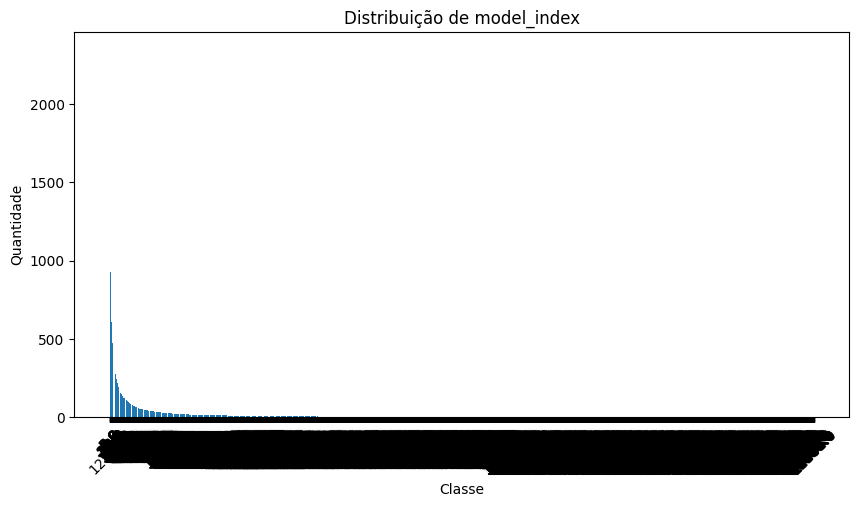

In [ ]:

# Converte vetor one-hot para índice da posição ativa
def onehot_to_index(v):
    if v is None:
        return None
    arr = v.toArray()
    if arr.sum() == 0:
        return -1
    return int(arr.argmax())

onehot_to_index_udf = udf(onehot_to_index, IntegerType())

onehot_cols = [
    "region_onehot",
    "manufacturer_onehot",
    "fuel_onehot",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot",
    "state_onehot",
    "title_status_onehot"
]

index_cols = [
    "transmission_index",
    "condition_index",
    "model_index"
]

df_plot = df_pre_treino

for c in onehot_cols:
    df_plot = df_plot.withColumn(c + "_class", onehot_to_index_udf(col(c)))

plot_cols = [c + "_class" for c in onehot_cols] + index_cols

for c in plot_cols:
    data = df_plot.groupBy(c) \
        .count() \
        .orderBy("count", ascending=False) \
        .collect()

    x = [str(row[c]) for row in data]
    y = [row["count"] for row in data]

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.title(f"Distribuição de {c}")
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45)
    plt.show()

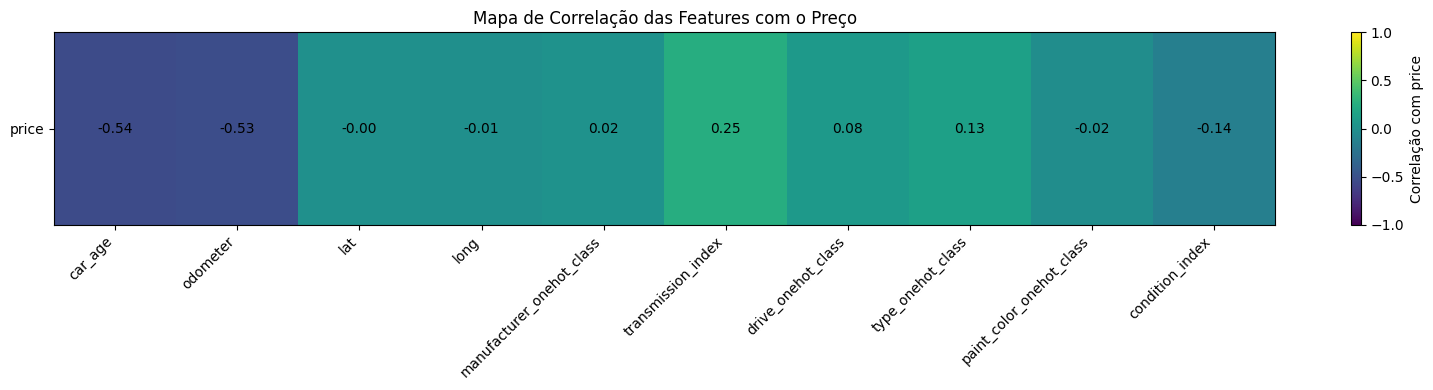

In [ ]:
from pyspark.sql.functions import col, udf, isnan
from pyspark.sql.types import IntegerType
import matplotlib.pyplot as plt
import numpy as np

def onehot_to_index(v):
    if v is None:
        return None

    arr = v.toArray()

    if arr.sum() == 0:
        return -1

    return int(arr.argmax())

onehot_to_index_udf = udf(onehot_to_index, IntegerType())

df_corr = df_pre_treino

onehot_cols = [
    "manufacturer_onehot",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot"
]

for c in onehot_cols:
    df_corr = df_corr.withColumn(
        c + "_class",
        onehot_to_index_udf(col(c))
    )

corr_cols = [
    "car_age",
    "odometer",
    "lat",
    "long",
    "manufacturer_onehot_class",
    "transmission_index",
    "drive_onehot_class",
    "type_onehot_class",
    "paint_color_onehot_class",
    "condition_index"
]

cols_necessarias = ["price"] + corr_cols

df_corr = df_corr.dropna(subset=cols_necessarias)

for c in cols_necessarias:
    df_corr = df_corr.filter(~isnan(col(c)))

correlations = []

for c in corr_cols:
    corr_value = df_corr.stat.corr("price", c)

    if corr_value is None:
        corr_value = 0.0

    correlations.append(corr_value)

corr_matrix = np.array([correlations])

plt.figure(figsize=(16, 4))
plt.imshow(corr_matrix, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlação com price")

plt.xticks(
    ticks=np.arange(len(corr_cols)),
    labels=corr_cols,
    rotation=45,
    ha="right"
)

plt.yticks([0], ["price"])
plt.title("Mapa de Correlação das Features com o Preço")

for i, value in enumerate(correlations):
    plt.text(
        i,
        0,
        f"{value:.2f}",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
df_pre_treino.count()


137458

Treinamento de Random Forest

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Lista dos atributos que você definiu (Features)
feature_cols = [
    "car_age",
    "odometer",
    "transmission_index",
    "drive_onehot",
    "type_onehot",
    "condition_index"
]

# Assembler: agrupa tudo em uma coluna chamada 'features'
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Transforma o DataFrame filtrado
df_model = assembler.transform(df_pre_treino).select("features", "price")

In [ ]:
# Lista de colunas que não podem ser nulas para o treino
cols_to_check = [
    "car_age",
    "odometer",
    "transmission_index",
    "type_onehot",
    "drive_onehot",
    "condition_index"
]

# Remove as linhas que possuem null em qualquer uma dessas colunas
df_pre_treino_clean = df_pre_treino.dropna(subset=cols_to_check)

# Agora use o df_pre_treino_clean no seu transform
df_model = assembler.transform(df_pre_treino_clean).select("features", "price")

In [ ]:
# 80% para treino e 20% para teste
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

In [ ]:
from pyspark.ml.regression import RandomForestRegressor

try:
    df_pre_treino.unpersist()
except:
    pass

train_data_repartitioned = train_data.repartition(8)

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="price",
    numTrees=50,
    maxDepth=13,
    seed=42
)

model = rf.fit(train_data_repartitioned)

In [ ]:
# Previsões no conjunto de teste
predictions = model.transform(test_data)

# Avaliadores
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print(f"RMSE (Erro médio): {rmse:.2f}")
print(f"R² (Precisão do modelo): {r2:.2f}")

# Mostrar as primeiras comparações entre Real e Previsto
predictions.select("price", "prediction").show(10)

RMSE (Erro médio): 4855.61
R² (Precisão do modelo): 0.67
+-------+------------------+
|  price|        prediction|
+-------+------------------+
| 6750.0| 22642.60354930419|
|15400.0|16166.544240844378|
|16200.0|14862.439034179748|
| 8999.0| 17016.93182933684|
| 7900.0|12228.726581789962|
|14500.0|15461.439953360248|
|13750.0|11440.265530731669|
| 7500.0| 13174.11733871697|
|11000.0|10034.401864274943|
| 6500.0| 9379.532686382068|
+-------+------------------+
only showing top 10 rows


Regressão Linear

In [191]:
import mlflow
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Lista dos atributos que você definiu (Features)
feature_cols = [
    "car_age",
    "odometer",
    "transmission_index",
    "drive_onehot",
    "type_onehot",
    "condition_index"
]

# Assembler: agrupa tudo em uma coluna chamada 'features'
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Transforma o DataFrame filtrado
df_model = assembler.transform(df_pre_treino).select("features", "price")

# Divisão de Treino e Teste
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

# Iniciando o rastreamento do experimento
with mlflow.start_run(run_name="regressao_linear_baseline"):

    # 1. Configuração da Regressão Linear
    lr = LinearRegression(
        featuresCol="features",
        labelCol="price",
        maxIter=100,
        regParam=0.1,       # Leve regularização para evitar overfitting
        elasticNetParam=0.0 # Define a regularização como Ridge (L2)
    )

    # 2. Treino propriamente dito
    lr_model = lr.fit(train_data)

    # 3. Previsões
    lr_predictions = lr_model.transform(test_data)

    # 4. Avaliação
    evaluator_r2 = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")
    evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")

    r2_lr = evaluator_r2.evaluate(lr_predictions)
    rmse_lr = evaluator_rmse.evaluate(lr_predictions)

    # 5. Registro automático das métricas no MLflow
    mlflow.log_param("maxIter", 100)
    mlflow.log_param("regParam", 0.1)
    mlflow.log_metric("r2", r2_lr)
    mlflow.log_metric("rmse", rmse_lr)

    print("--- Regressão Linear ---")
    print(f"R²:   {r2_lr:.4f}")
    print(f"RMSE: {rmse_lr:.4f}\n")

# Visualização das primeiras previsões
lr_predictions.select("price", "prediction").show(10)

2026/05/03 14:19:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 14:19:36 INFO mlflow.store.db.utils: Updating database tables


--- Regressão Linear ---
R²:   0.4425
RMSE: 5508.0445

+-------+------------------+
|  price|        prediction|
+-------+------------------+
|18280.0|19743.042474043323|
|25695.0|18902.293574294534|
|27547.0|19759.413180643453|
|21994.0| 19684.63878852161|
|24581.0| 19612.99211902743|
|19995.0| 18656.07633953535|
|17550.0|19404.889457684436|
|21695.0|18462.375749826722|
|12999.0|18740.793932322144|
|18900.0|17697.247509817305|
+-------+------------------+
only showing top 10 rows


Modelo de rede neural

In [192]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import r2_score

# ============================================================
# 1. Preparação e Normalização dos Dados
# ============================================================
# Coletando dados do Spark
dados = df_model.select("features", "price").dropna().collect()

X_raw = np.array([row["features"].toArray() for row in dados], dtype=np.float32)
y_raw = np.array([row["price"] for row in dados], dtype=np.float32).reshape(-1, 1)

# Normalização Z-Score (Média 0, Desvio 1)
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0)
X_std[X_std == 0] = 1.0
X_scaled = (X_raw - X_mean) / X_std

y_mean, y_std = y_raw.mean(), y_raw.std()
y_scaled = (y_raw - y_mean) / y_std

# Divisão de Treino e Teste (80/20)
indices = np.random.permutation(len(X_scaled))
train_idx, test_idx = indices[:int(0.8*len(X_scaled))], indices[int(0.8*len(X_scaled)):]

# Criação dos Tensores e DataLoaders (Mini-batches de 64)
train_dataset = TensorDataset(torch.tensor(X_scaled[train_idx]), torch.tensor(y_scaled[train_idx]))
test_dataset = TensorDataset(torch.tensor(X_scaled[test_idx]), torch.tensor(y_scaled[test_idx]))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
X_test_tensor = torch.tensor(X_scaled[test_idx])
y_test_tensor = torch.tensor(y_scaled[test_idx])

# ============================================================
# 2. Arquitetura da Rede (MLP)
# ============================================================


class CarPriceNet(nn.Module):
    def __init__(self, input_dim):
        super(CarPriceNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.layers(x)

model = CarPriceNet(X_scaled.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ============================================================
# 3. Loop de Treinamento
# ============================================================
epochs = 100
for epoch in range(epochs):
    model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    if epoch % 20 == 0:
        print(f"Época {epoch}/{epochs} | Loss: {loss.item():.4f}")

# ============================================================
# 4. Avaliação Final (Resultados Reais)
# ============================================================
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor).numpy()

# Voltando para a escala em Dólares
y_pred_final = (y_pred_scaled * y_std) + y_mean
y_test_final = (y_test_tensor.numpy() * y_std) + y_mean

# Métricas
rmse = np.sqrt(np.mean((y_pred_final - y_test_final)**2))
mae = np.mean(np.abs(y_pred_final - y_test_final))
r2 = r2_score(y_test_final, y_pred_final)

print("\n" + "="*30)
print("RELATÓRIO FINAL: REDE NEURAL")
print(f"R² (Precisão): {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print("="*30)

Época 0/100 | Loss: 0.3872
Época 20/100 | Loss: 0.4108
Época 40/100 | Loss: 0.6487
Época 60/100 | Loss: 0.6109
Época 80/100 | Loss: 0.4850

RELATÓRIO FINAL: REDE NEURAL
R² (Precisão): 0.5154
RMSE: $5,173.82
MAE:  $3,940.03
